In [4]:
import os
import json
import pickle
import datetime as dt

import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from Functions import (cost_per_sample, generate_legal_neighbors, barker, compute_A)

# Slightly larger default axis label / tick sizes for every plot in this notebook
plt.rcParams.update({
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

In [5]:
# ---- Backup / output setup ----
# Everything (checkpoints, final arrays, figures) gets written here, timestamped,
# so a crashed kernel or an overwritten variable never costs you the whole run.
RUN_ID = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
OUTPUT_DIR = f"run_{RUN_ID}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(OUTPUT_DIR, "checkpoint.pkl")

print(f"Output directory: {OUTPUT_DIR}")

def save_figure(fig, name):
    """Save a figure as both PNG (quick viewing) and SVG (vector, for editing/papers)."""
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")
    fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.svg"), bbox_inches="tight")

def save_checkpoint(state):
    """Overwrite the checkpoint file with the current training state.
    Called periodically during the loop so a crash mid-run doesn't lose everything."""
    tmp_path = CHECKPOINT_PATH + ".tmp"
    with open(tmp_path, "wb") as f:
        pickle.dump(state, f)
    os.replace(tmp_path, CHECKPOINT_PATH)  # atomic on POSIX: avoids a half-written file

Output directory: run_20260718_172543


In [6]:
#function
def RL_trajectory_schedule(d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks):
    d = d0.copy()
    E_current = cost_per_sample(Gamma, A, H, d)
    grad_logP = np.zeros(num_blocks)

    for t in range(num_time_steps):
        neighbors = generate_legal_neighbors(d)
        if len(neighbors) == 0:
            break

        block = t // block_size
        beta_t = beta_schedule[block]
        j = np.random.randint(len(neighbors))
        d_prime = neighbors[j]
        E_prime = cost_per_sample(Gamma, A, H, d_prime)
        deltaE = E_prime - E_current

        A_accept = barker(deltaE, beta_t)
        u = np.random.uniform(0, 1)
        if u < A_accept:
            grad_logP[block] += -deltaE / (1 + np.exp(-beta_t * deltaE))
            d, E_current = d_prime, E_prime
        else:
            grad_logP[block] += deltaE / (1 + np.exp(beta_t * deltaE))

    return d, E_current, grad_logP


def run_experiment(d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks):
    _, E_final, grad_logP = RL_trajectory_schedule(
        d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks
    )
    return E_final, grad_logP


def grad_expectedcost_schedule(d0, Gamma, beta_schedule, num_time_steps,
                                num_independent_experiments, block_size, num_blocks):
    H = 1
    A = compute_A(Gamma)
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(run_experiment)(
            d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks)
        for _ in range(num_independent_experiments)
    )

    costs = np.zeros(num_independent_experiments)
    grad_matrix = np.zeros((num_independent_experiments, num_blocks))

    for i, (E_final, grad_logP) in enumerate(results):
        costs[i] = E_final
        grad_matrix[i] = grad_logP

    # baseline-subtracted (variance-reduced) REINFORCE estimator
    baseline = np.mean(costs)
    grad_beta_schedule = np.mean((costs - baseline)[:, None] * grad_matrix, axis=0)

    return costs, grad_beta_schedule


def update_beta_schedule(beta_schedule, grad_beta_schedule, learning_rate):
    beta_schedule = beta_schedule - learning_rate * grad_beta_schedule
    return np.clip(beta_schedule, 0.0, None)


def evaluate_schedule(d0, Gamma, beta_schedule, num_time_steps, num_eval_experiments,
                       block_size, num_blocks):
    """Run fresh, independent trajectories under a fixed schedule (no gradient
    tracking needed) and report the resulting energy distribution. Used for a
    held-out comparison that isn't contaminated by the trajectories used to
    fit beta_schedule."""
    H = 1
    A = compute_A(Gamma)
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(run_experiment)(
            d0, Gamma, A, H, beta_schedule, num_time_steps, block_size, num_blocks)
        for _ in range(num_eval_experiments)
    )
    costs = np.array([E_final for E_final, _ in results])
    return costs

In [7]:
#parameters
H = 1
P = 0
Gamma = [H,P,H,P,P,H,H,P,H,P,P,H,P,H,H,P,P,H,P,H]  # 20-bead sequence
assert len(Gamma) == 20
d0 = [1] * (len(Gamma) - 1)  # initial fold: straight chain

num_time_steps = 10000
num_independent_experiments = 100
learning_rate = 0.1
num_iterations = 500
block_size = 500  # watch the gradient signal per block
num_blocks = num_time_steps // block_size

num_eval_experiments = 500  # held-out trajectories for final evaluation

snapshot_every = 50     # iterations between recorded schedule snapshots (for the evolution plot)
checkpoint_every = 20    # iterations between on-disk checkpoints (backup safety net)

beta_schedule = np.full(num_blocks, 0.1)
print(f"num_blocks = {num_blocks}, block_size = {block_size}")

num_blocks = 20, block_size = 500


In [8]:
import time
t0 = time.time()
costs, grad = grad_expectedcost_schedule(
    d0, Gamma, beta_schedule, num_time_steps,
    num_independent_experiments, block_size, num_blocks
)
elapsed = time.time() - t0
print(f"one iteration took {elapsed:.1f}s")
print(f"estimated total for {num_iterations} iterations: {elapsed*num_iterations/60:.1f} min ({elapsed*num_iterations/3600:.1f} hr)")

one iteration took 54.4s
estimated total for 500 iterations: 453.2 min (7.6 hr)


In [9]:
# training loop
cost_history = []
grad_norm_history = []      # NEW: ||grad|| each iteration -- flags instability/overshoot
frac_zero_history = []      # NEW: fraction of beta_schedule pinned at the 0.0 clamp floor
schedule_snapshots = []
best_beta_schedule = beta_schedule.copy()
best_cost_so_far = np.inf

def _ckpt_state(iteration):
    return {
        "iteration": iteration,
        "beta_schedule": beta_schedule,
        "best_beta_schedule": best_beta_schedule,
        "best_cost_so_far": best_cost_so_far,
        "cost_history": cost_history,
        "grad_norm_history": grad_norm_history,
        "frac_zero_history": frac_zero_history,
        "schedule_snapshots": schedule_snapshots,
        "Gamma": Gamma,
        "d0": d0,
        "num_time_steps": num_time_steps,
        "block_size": block_size,
        "num_blocks": num_blocks,
    }

try:
    for iteration in range(num_iterations):
        costs, grad = grad_expectedcost_schedule(
            d0, Gamma, beta_schedule, num_time_steps,
            num_independent_experiments, block_size, num_blocks
        )
        beta_schedule = update_beta_schedule(beta_schedule, grad, learning_rate)
        mean_cost = np.mean(costs)
        cost_history.append(mean_cost)

        # ---- grad_norm diagnostic ----
        grad_norm = np.linalg.norm(grad)
        frac_zero = np.mean(beta_schedule == 0.0)
        grad_norm_history.append(grad_norm)
        frac_zero_history.append(frac_zero)

        if mean_cost < best_cost_so_far:
            best_cost_so_far = mean_cost
            best_beta_schedule = beta_schedule.copy()

        if iteration % snapshot_every == 0:
            schedule_snapshots.append(beta_schedule.copy())

        if iteration % checkpoint_every == 0:
            save_checkpoint(_ckpt_state(iteration))

        if iteration % 20 == 0:
            print(f"Iter {iteration:4d}  beta[0]={beta_schedule[0]:.4f}  "
                  f"beta[-1]={beta_schedule[-1]:.4f}  avg cost={mean_cost:.4f}  "
                  f"grad_norm={grad_norm:.4f}  frac_at_zero={frac_zero:.2f}")
            if frac_zero > 0.3:
                print(f"    ! {frac_zero:.0%} of beta_schedule is pinned at 0 -- "
                      f"likely overshooting. Consider lowering learning_rate.")

except KeyboardInterrupt:
    print("Training interrupted -- saving current state to checkpoint before stopping.")
    save_checkpoint(_ckpt_state(iteration))
    raise

# final checkpoint after a clean finish
save_checkpoint(_ckpt_state(num_iterations - 1))
print("Training complete. Checkpoint saved to", CHECKPOINT_PATH)

Iter    0  beta[0]=0.1173  beta[-1]=0.2164  avg cost=-0.8400  grad_norm=2.3263  frac_at_zero=0.00
Iter   20  beta[0]=0.2699  beta[-1]=2.8709  avg cost=-5.1500  grad_norm=3.5846  frac_at_zero=0.10
Iter   40  beta[0]=0.7383  beta[-1]=3.5688  avg cost=-5.3700  grad_norm=4.7781  frac_at_zero=0.10
Iter   60  beta[0]=1.0510  beta[-1]=3.4673  avg cost=-5.8800  grad_norm=3.6604  frac_at_zero=0.05
Iter   80  beta[0]=2.0121  beta[-1]=3.7937  avg cost=-6.0200  grad_norm=3.1587  frac_at_zero=0.05
Iter  100  beta[0]=2.1087  beta[-1]=3.9003  avg cost=-6.3100  grad_norm=4.2046  frac_at_zero=0.05
Iter  120  beta[0]=1.9107  beta[-1]=4.0425  avg cost=-6.1300  grad_norm=3.0528  frac_at_zero=0.00
Iter  140  beta[0]=2.1381  beta[-1]=4.0055  avg cost=-6.0800  grad_norm=2.9352  frac_at_zero=0.00
Iter  160  beta[0]=1.9500  beta[-1]=4.2387  avg cost=-6.1900  grad_norm=2.7684  frac_at_zero=0.05
Iter  180  beta[0]=2.0482  beta[-1]=4.2878  avg cost=-6.4700  grad_norm=2.7229  frac_at_zero=0.00
Iter  200  beta[0]=1

In [10]:
import pickle, os

CHECKPOINT_PATH = os.path.join("run_20260716_194049", "checkpoint.pkl")  # your actual folder
with open(CHECKPOINT_PATH, "rb") as f:
    state = pickle.load(f)

beta_schedule = state["beta_schedule"]
best_beta_schedule = state["best_beta_schedule"]
best_cost_so_far = state["best_cost_so_far"]
cost_history = state["cost_history"]
# .get(...) with a fallback so this still loads an older checkpoint saved before
# grad_norm_history/frac_zero_history existed
grad_norm_history = state.get("grad_norm_history", [])
frac_zero_history = state.get("frac_zero_history", [])
schedule_snapshots = state["schedule_snapshots"]
iteration = state["iteration"]

print(f"Restored from iteration {iteration}, {len(cost_history)} cost entries so far")

FileNotFoundError: [Errno 2] No such file or directory: 'run_20260716_194049\\checkpoint.pkl'

In [ ]:
start_iteration = iteration + 1  # 'iteration' still holds the last completed step
print(f"Resuming from iteration {start_iteration} up to {num_iterations}")

def _ckpt_state(iteration):
    return {
        "iteration": iteration,
        "beta_schedule": beta_schedule,
        "best_beta_schedule": best_beta_schedule,
        "best_cost_so_far": best_cost_so_far,
        "cost_history": cost_history,
        "grad_norm_history": grad_norm_history,
        "frac_zero_history": frac_zero_history,
        "schedule_snapshots": schedule_snapshots,
        "Gamma": Gamma,
        "d0": d0,
        "num_time_steps": num_time_steps,
        "block_size": block_size,
        "num_blocks": num_blocks,
    }

try:
    for iteration in range(start_iteration, num_iterations):
        costs, grad = grad_expectedcost_schedule(
            d0, Gamma, beta_schedule, num_time_steps,
            num_independent_experiments, block_size, num_blocks
        )
        beta_schedule = update_beta_schedule(beta_schedule, grad, learning_rate)
        mean_cost = np.mean(costs)
        cost_history.append(mean_cost)

        grad_norm = np.linalg.norm(grad)
        frac_zero = np.mean(beta_schedule == 0.0)
        grad_norm_history.append(grad_norm)
        frac_zero_history.append(frac_zero)

        if mean_cost < best_cost_so_far:
            best_cost_so_far = mean_cost
            best_beta_schedule = beta_schedule.copy()

        if iteration % snapshot_every == 0:
            schedule_snapshots.append(beta_schedule.copy())

        if iteration % checkpoint_every == 0:
            save_checkpoint(_ckpt_state(iteration))

        if iteration % 20 == 0:
            print(f"Iter {iteration:4d}  beta[0]={beta_schedule[0]:.4f}  "
                  f"beta[-1]={beta_schedule[-1]:.4f}  avg cost={mean_cost:.4f}  "
                  f"grad_norm={grad_norm:.4f}  frac_at_zero={frac_zero:.2f}")
            if frac_zero > 0.3:
                print(f"    ! {frac_zero:.0%} of beta_schedule is pinned at 0 -- "
                      f"likely overshooting. Consider lowering learning_rate.")

except KeyboardInterrupt:
    print("Interrupted again -- saving checkpoint.")
    save_checkpoint(_ckpt_state(iteration))
    raise

save_checkpoint(_ckpt_state(num_iterations - 1))
print("Training complete. Checkpoint saved to", CHECKPOINT_PATH)

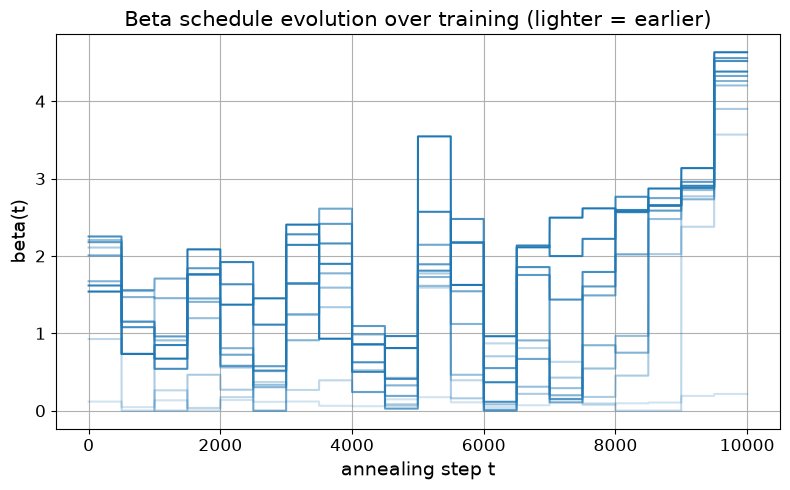

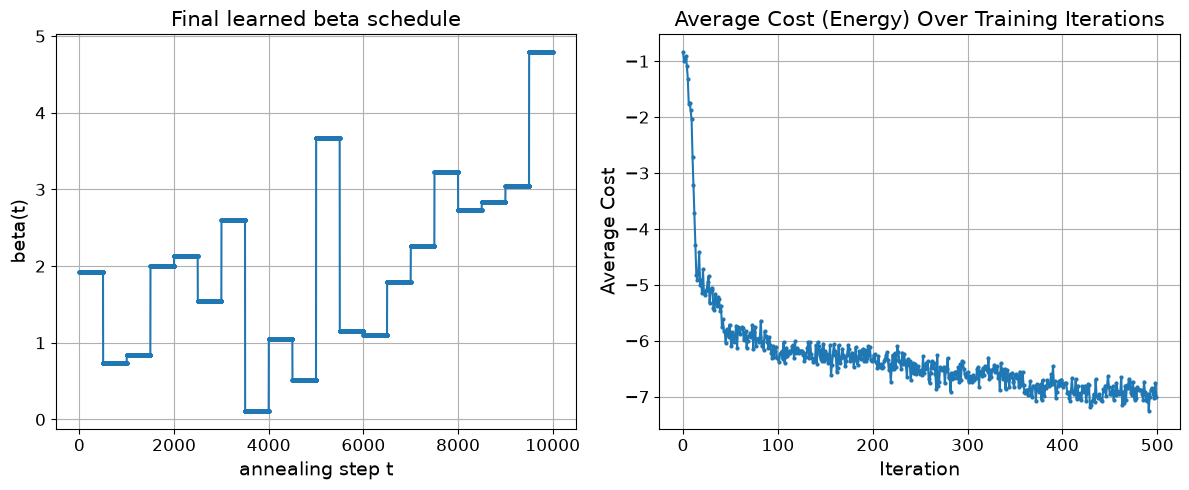

In [11]:
plt.figure(figsize=(8, 5))
for i, snap in enumerate(schedule_snapshots):
    alpha = 0.2 + 0.8 * (i / max(len(schedule_snapshots) - 1, 1))
    plt.plot(np.repeat(snap, block_size), color='C0', alpha=alpha)
plt.xlabel("annealing step t")
plt.ylabel("beta(t)")
plt.title("Beta schedule evolution over training (lighter = earlier)")
plt.grid(True)
plt.tight_layout()
plt.show()

# final schedule + cost convergence

beta_full = np.repeat(beta_schedule, block_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(beta_full, marker='o', markersize=2)
axes[0].set_title("Final learned beta schedule")
axes[0].set_xlabel("annealing step t")
axes[0].set_ylabel("beta(t)")
axes[0].grid(True)

axes[1].plot(cost_history, marker='o', markersize=2)
axes[1].set_title("Average Cost (Energy) Over Training Iterations")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Average Cost")
axes[1].grid(True)

plt.tight_layout()
plt.show()

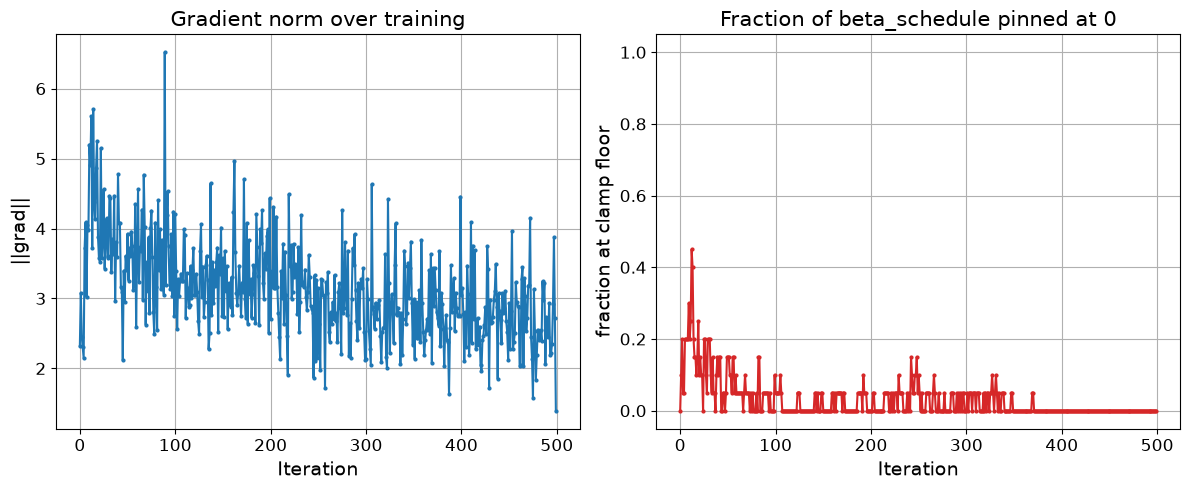

In [12]:
# ---- Gradient diagnostics: did training destabilize / overshoot at any point? ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(grad_norm_history, marker='o', markersize=2)
axes[0].set_title("Gradient norm over training")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("||grad||")
axes[0].grid(True)

axes[1].plot(frac_zero_history, marker='o', markersize=2, color='C3')
axes[1].set_title("Fraction of beta_schedule pinned at 0")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("fraction at clamp floor")
axes[1].set_ylim(-0.05, 1.05)
axes[1].grid(True)

plt.tight_layout()
save_figure(fig, "grad_diagnostics")
plt.show()

# Rule of thumb for reading these:
# - grad_norm should generally shrink (with noise) as beta_schedule converges.
#   A grad_norm that stays large/spiky throughout usually means the batch
#   (num_independent_experiments) is too small relative to trajectory variance.
# - frac_at_zero spiking toward 1.0 early and staying there means the learning_rate
#   is too high -- the update is repeatedly overshooting past 0 and getting clamped,
#   which can stall learning for those blocks entirely (gradient at the clamp
#   boundary may itself be small, so it can get stuck).


In [13]:
num_eval_experiments = 1000
final_costs = evaluate_schedule(d0, Gamma, beta_schedule, num_time_steps,
                                 num_eval_experiments, block_size, num_blocks)
best_costs = evaluate_schedule(d0, Gamma, best_beta_schedule, num_time_steps,
                                num_eval_experiments, block_size, num_blocks)

print(f"final schedule: mean={final_costs.mean():.3f} std={final_costs.std():.3f} "
      f"success_prob={np.mean(final_costs==-9):.3f}")
print(f"best-seen schedule: mean={best_costs.mean():.3f} std={best_costs.std():.3f} "
      f"success_prob={np.mean(best_costs==-9):.3f}")

final schedule: mean=-6.911 std=1.162 success_prob=0.086
best-seen schedule: mean=-6.897 std=1.168 success_prob=0.088


In [14]:
import pickle
import numpy as np

# 1. Pickle -- exact objects, easiest to reload later in Python
with open("reinforce_beta_schedules.pkl", "wb") as f:
    pickle.dump({
        "beta_schedule": beta_schedule,              # final schedule at end of training
        "best_beta_schedule": best_beta_schedule,     # lowest-cost schedule seen during training
        "best_cost_so_far": best_cost_so_far,
        "schedule_snapshots": schedule_snapshots,     # list of schedules over training (evolution plot data)
        "cost_history": cost_history,
        "grad_norm_history": grad_norm_history,
        "frac_zero_history": frac_zero_history,
        "block_size": block_size,
        "num_blocks": num_blocks,
        "num_time_steps": num_time_steps,
    }, f)

# 2. CSV of the two schedules that actually matter for your benchmark comparison
import pandas as pd
schedule_df = pd.DataFrame({
    "block": np.arange(num_blocks),
    "beta_final": beta_schedule,
    "beta_best_seen": best_beta_schedule,
})
schedule_df.to_csv("reinforce_beta_schedules.csv", index=False)

# 3. CSV of the full evolution (every snapshot), useful if you want to replot or inspect later
snapshot_df = pd.DataFrame(
    np.array(schedule_snapshots),
    columns=[f"block_{i}" for i in range(num_blocks)]
)
snapshot_df.insert(0, "snapshot_iteration", np.arange(len(schedule_snapshots)) * snapshot_every)
snapshot_df.to_csv("reinforce_schedule_evolution.csv", index=False)

print("saved: reinforce_beta_schedules.pkl, reinforce_beta_schedules.csv, reinforce_schedule_evolution.csv")

import os
print(os.listdir())

saved: reinforce_beta_schedules.pkl, reinforce_beta_schedules.csv, reinforce_schedule_evolution.csv
['20-bead_REINFORCE.ipynb', 'Functions.py', 'reinforce_beta_schedules.csv', 'reinforce_beta_schedules.pkl', 'reinforce_schedule_evolution.csv', 'run_20260718_172539', 'run_20260718_172543', '__pycache__']
